In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.4 MB/s eta 0:00:00


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['Brent Oil Futures Historical Data.csv'].decode('utf-8')), index_col='Date', parse_dates=True)

Saving Brent Oil Futures Historical Data.csv to Brent Oil Futures Historical Data.csv


<Axes: xlabel='Date'>

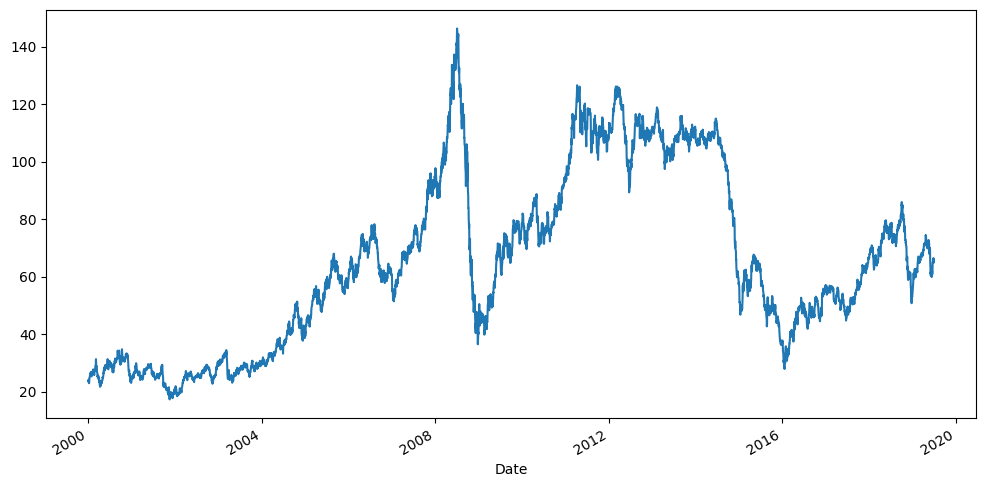

In [4]:
data["Open"].plot(figsize=(12,6))

In [5]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [6]:
ad_test(data['Price'])

1. ADF:  -1.6186462793319805
2. p-value:  0.47343907294313814
3. No. of lags:  26
4. No. of observations used for ADF Regression and Critical Values Calculations:  4973
5. Critical Values: 
	 1% , -3.431665640184842
	 5% , -2.8621213700013244
	 10% , -2.567079464076049


In [7]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [8]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16997.802, Time=18.34 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17015.033, Time=0.42 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=17001.557, Time=0.65 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=17001.271, Time=1.43 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=17013.221, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=17005.011, Time=6.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=17004.929, Time=3.36 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16994.971, Time=7.90 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16993.729, Time=6.76 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=17004.823, Time=1.03 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16992.310, Time=6.78 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=16997.208, Time=1.20 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=16992.360, Time=6.51 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=16983.994, Time=14.24 sec
 ARIMA(5,1,2)(0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 5000
Model:               SARIMAX(4, 1, 2)   Log Likelihood               -8483.936
Date:                Thu, 18 May 2023   AIC                          16981.871
Time:                        04:41:16   BIC                          17027.490
Sample:                             0   HQIC                         16997.860
                               - 5000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0040      0.033     -0.121      0.904      -0.069       0.061
ar.L2          0.8485      0.034     24.726      0.000       0.781       0.916
ar.L3          0.0444      0.010      4.295      0.000       0.024       0.065
ar.L4          0.0464      0.010      4.854      0.000       0.028       0.065
ma.L1         -0.0526      0.032     -1.624      0.104      -0.116       0.011
ma.L2         -0.8613      0.035    -24.288      0.000      -0.931      -0.792
sigma2         1.7443      0.020     87.116      0.000       1.705       1.784
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4162.92
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.48   Skew:                             0.20
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [10]:
# Converting "Vol." column to float datatype
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000
print(data.dtypes)

Price    float64
Open     float64
High     float64
Low      float64
Vol.     float64
dtype: object


In [11]:
import statsmodels.api as sm

In [18]:
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-100]
test=data.iloc[-100:]
print(train.shape, test.shape)

(5000, 5)
(4900, 5) (100, 5)


In [20]:
# Taining the model
model=sm.tsa.arima.ARIMA(train['Price'], order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 4900
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -8361.641
Date:                Thu, 18 May 2023   AIC                          16739.282
Time:                        04:44:56   BIC                          16791.258
Sample:                             0   HQIC                         16757.517
                               - 4900                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.1215     27.179      2.433      0.015      12.852     119.392
ar.L1          0.9992      0.001   1728.638      0.000       0.998       1.000
ma.L1         -0.0544      0.010     -5.527      0.000      -0.074      -0.035
ma.L2         -0.0079      0.009     -0.851      0.395      -0.026       0.010
ma.L3          0.0072      0.010      0.707      0.479      -0.013       0.027
ma.L4          0.0410      0.010      4.155      0.000       0.022       0.060
ma.L5         -0.0193      0.010     -1.989      0.047      -0.038      -0.000
sigma2         1.7749      0.021     85.261      0.000       1.734       1.816
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4035.62
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.49   Skew:                             0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [21]:
# Make predictions on the Test dataset
start = len(train)
end = len(train) + len(test)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

4900    29.218484
4901    29.210657
4902    29.280240
4903    29.306480
4904    29.330060
          ...    
4995    31.784449
4996    31.810490
4997    31.836511
4998    31.862513
4999    31.888495
Name: predicted_mean, Length: 100, dtype: float64
Date
2000-05-25    29.218484
2000-05-24    29.210657
2000-05-23    29.280240
2000-05-22    29.306480
2000-05-19    29.330060
                ...    
2000-01-10    31.784449
2000-01-07    31.810490
2000-01-06    31.836511
2000-01-05    31.862513
2000-01-04    31.888495
Name: predicted_mean, Length: 100, dtype: float64


<Axes: xlabel='Date'>

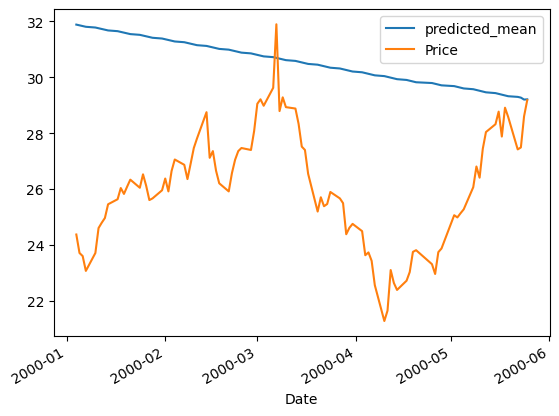

In [22]:
# Plotting the predicted values and the test set
pred.plot(legend=True)
test['Price'].plot(legend=True)

In [23]:
test['Price'].mean()

26.063200000000002

In [24]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test['Price'], pred))
print(rmse)

5.007313434769219
